# Data understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:

# Load Dataset
df = pd.read_csv('data/raw/breast-cancer.csv')

# Display first 5 rows
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# DATASET INFORMATION

## Number of rows and columns  
print("Dataset Shape:", df.shape)

## Display column names
print("Columns:\n", df.columns.tolist())


Dataset Shape: (569, 32)
Columns:
 ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [4]:
## General info about dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [5]:
## Check missing values
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [6]:
## Summary statistics
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [7]:
# Target Variable Analysis

## Count values in target column (diagnosis)
df['diagnosis'].value_counts()

## Percentage distribution
df['diagnosis'].value_counts(normalize=True) * 100

diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64

In [8]:
# Check for Duplicates
## Rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


# Outlier detection , removal & visualization

In [9]:
# drop the id column (not useful for analysis)
df = df.drop(columns=['id'])

# encode diagnosis: M (Malignant) = 1, B (Benign) = 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

df.head(3)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


#### Detect outliers using the IQR method

In [10]:
num_col = df.select_dtypes(include=np.number).columns.drop('diagnosis')
print(num_col.tolist())



['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [11]:
#now we check for outliers
q1  = df[num_col].quantile(0.25)
q3  = df[num_col].quantile(0.75)
iqr = q3 - q1

outlier_mask = (df[num_col] < (q1 - 1.5 * iqr)) | (df[num_col] > (q3 + 1.5 * iqr))

outlier_counts = outlier_mask.sum()
print(outlier_counts)

# detect rows where ANY column is an outlier
row_outlier_mask = outlier_mask.any(axis=1)

# total number of outlier rows
outlier_count = row_outlier_mask.sum()
print(outlier_count)

radius_mean                14
texture_mean                7
perimeter_mean             13
area_mean                  25
smoothness_mean             6
compactness_mean           16
concavity_mean             18
concave points_mean        10
symmetry_mean              15
fractal_dimension_mean     15
radius_se                  38
texture_se                 20
perimeter_se               38
area_se                    65
smoothness_se              30
compactness_se             28
concavity_se               22
concave points_se          19
symmetry_se                27
fractal_dimension_se       28
radius_worst               17
texture_worst               5
perimeter_worst            15
area_worst                 35
smoothness_worst            7
compactness_worst          16
concavity_worst            12
concave points_worst        0
symmetry_worst             23
fractal_dimension_worst    24
dtype: int64
171


In [12]:
# Outliers per column using IQR method (detailed list)
print("Outliers per column using IQR method:")
print(outlier_counts.values)
print("\nTotal rows with outliers (IQR):", outlier_count)

Outliers per column using IQR method:
[14  7 13 25  6 16 18 10 15 15 38 20 38 65 30 28 22 19 27 28 17  5 15 35
  7 16 12  0 23 24]

Total rows with outliers (IQR): 171


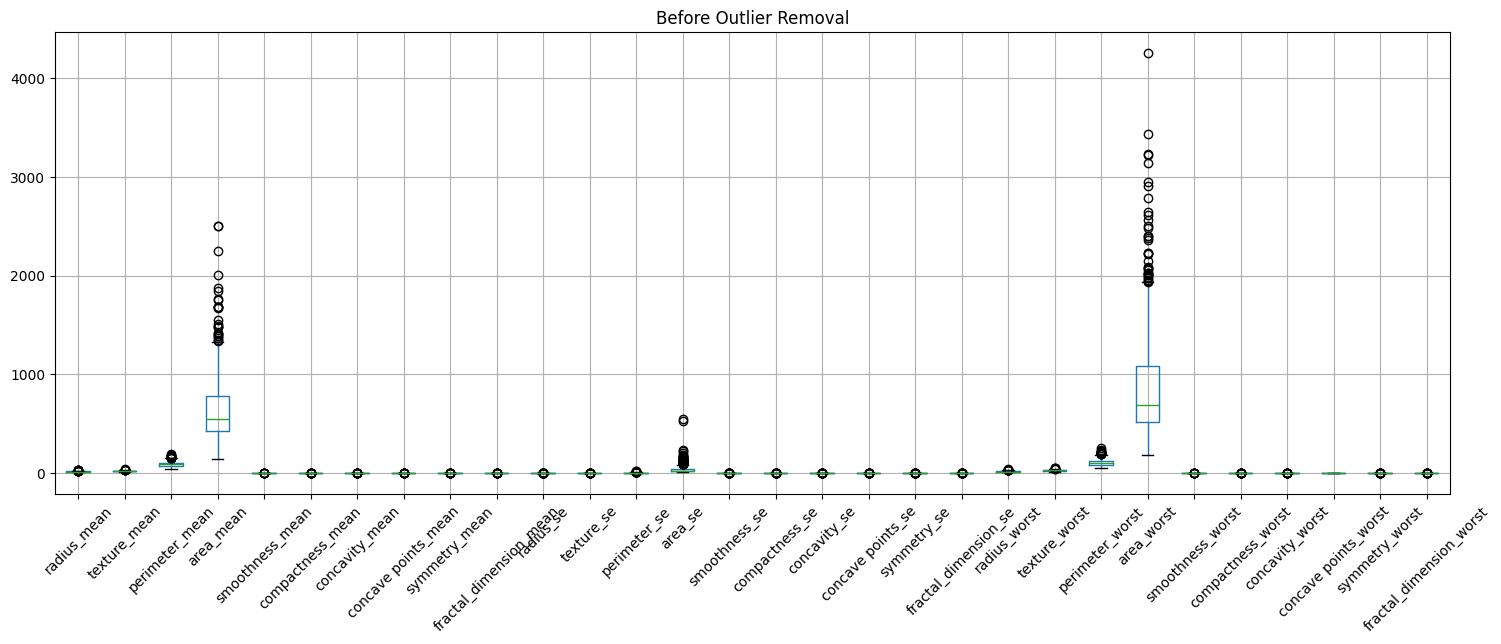

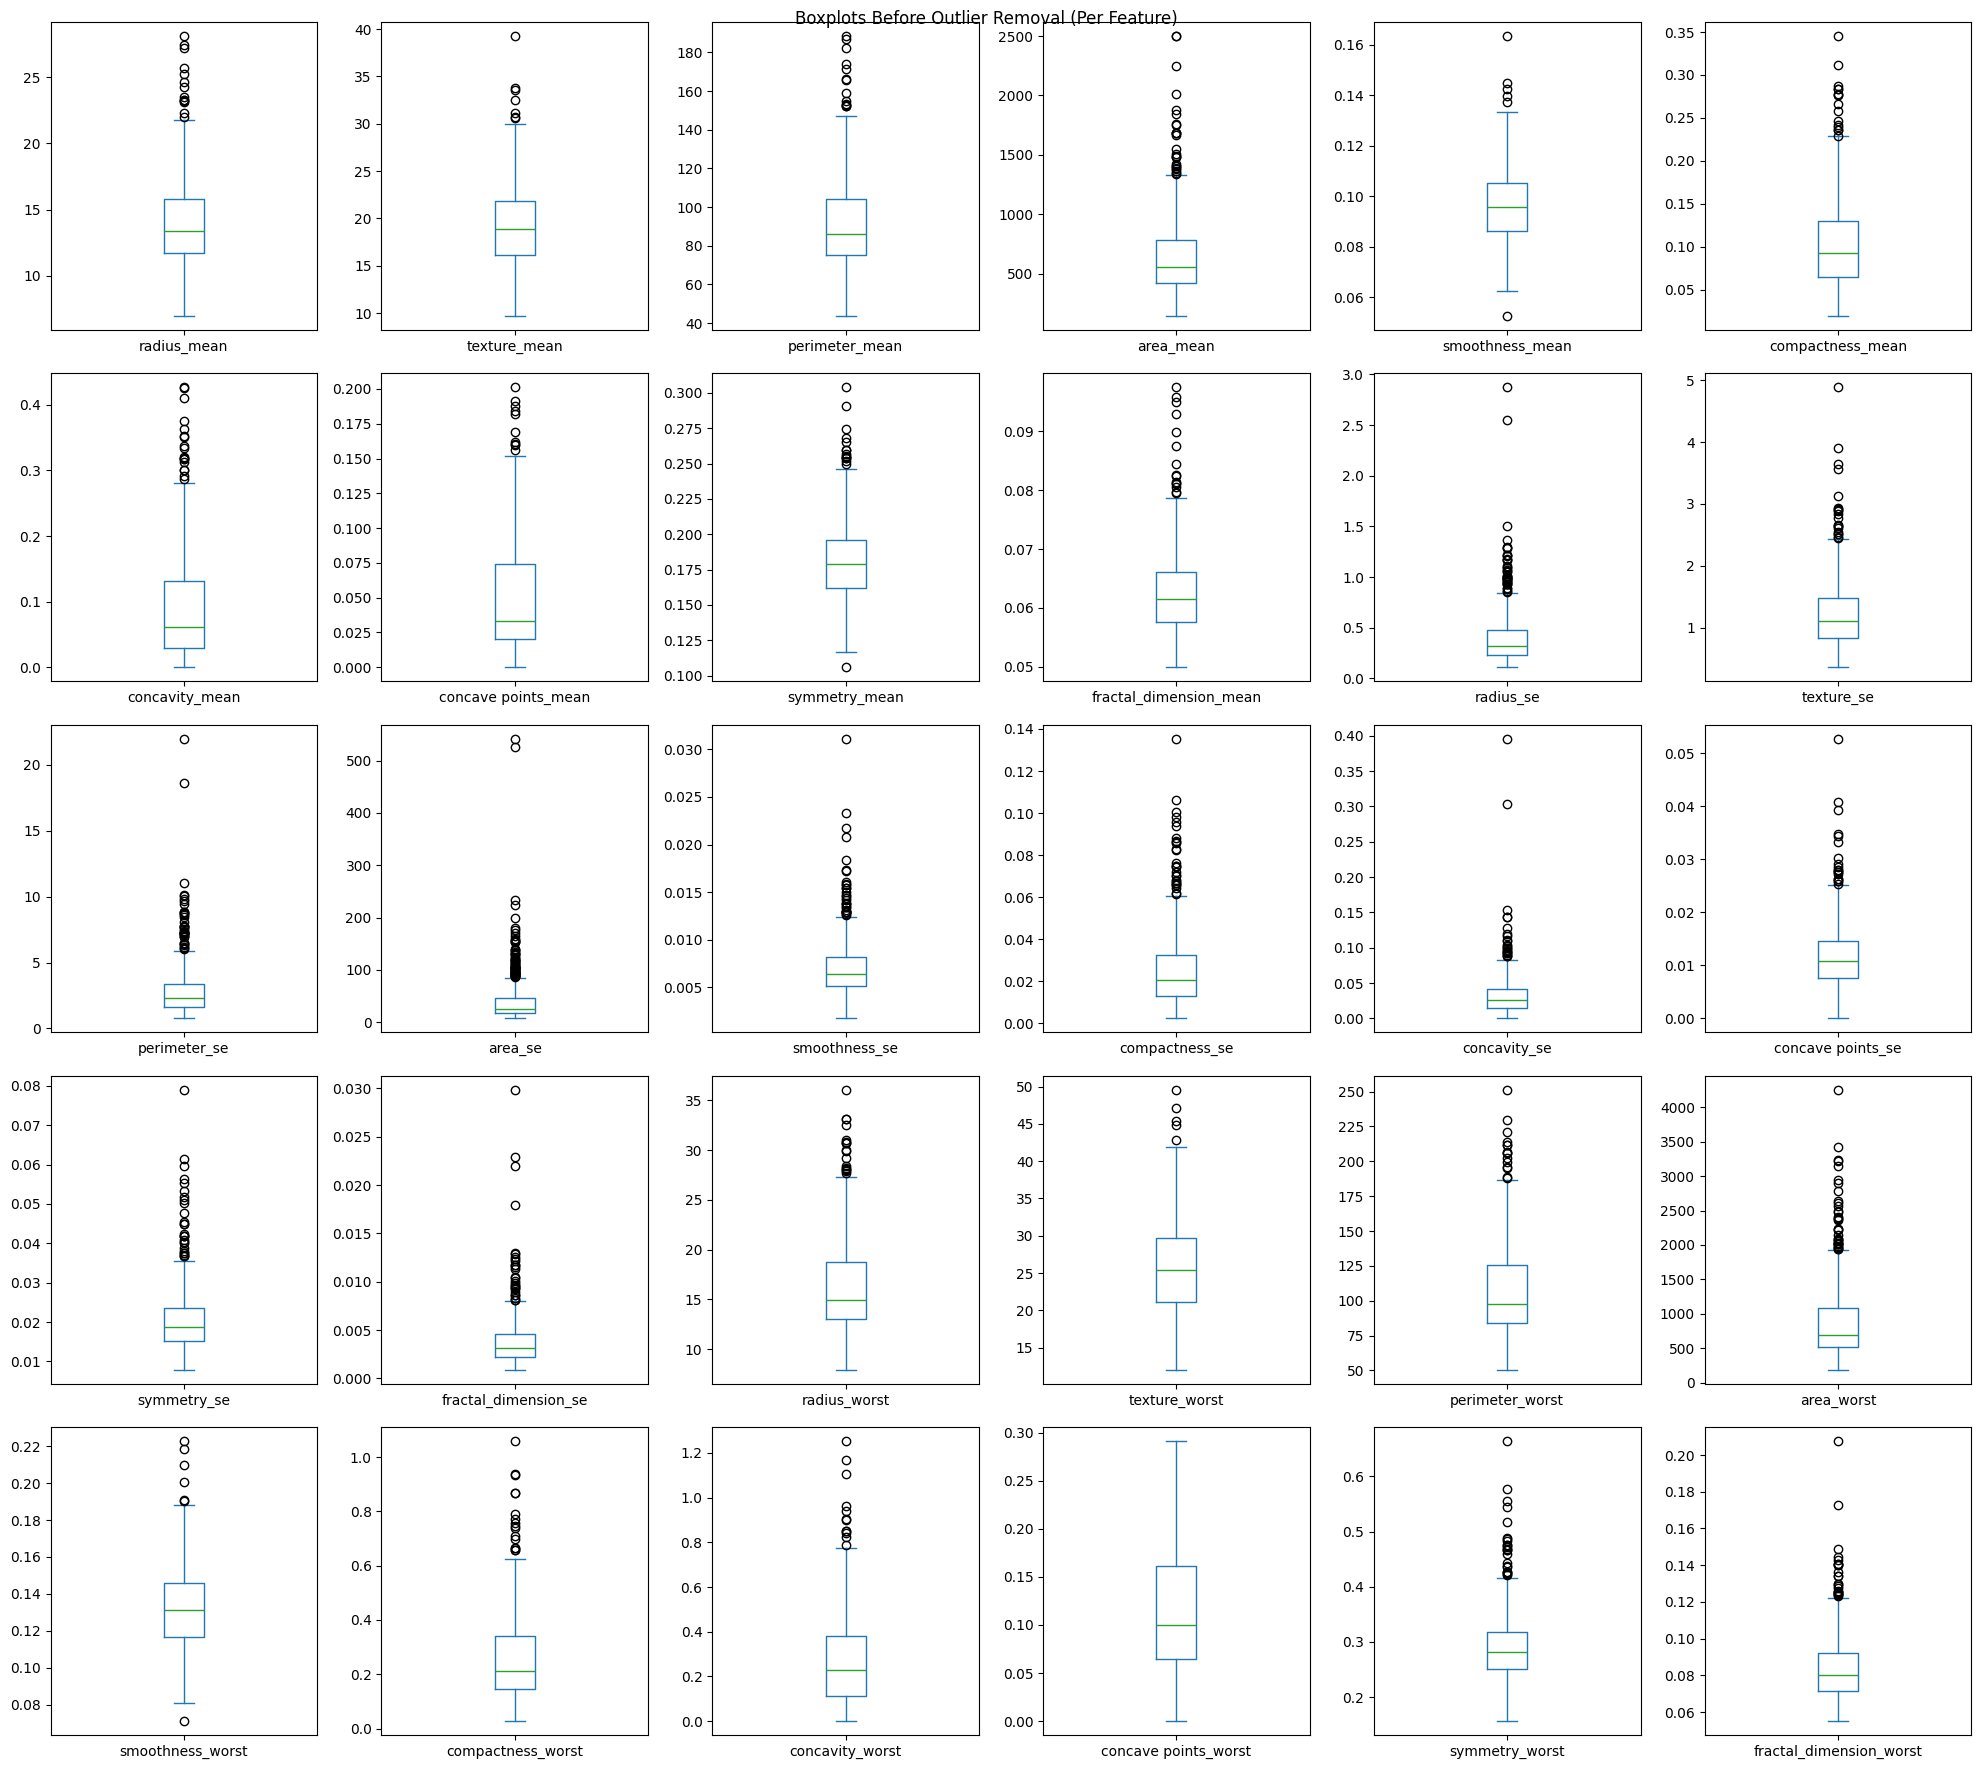

In [13]:

# before removing outliers
plt.figure(figsize=(18, 6))
df[num_col].boxplot()
plt.title("Before Outlier Removal")
plt.xticks(rotation=45)
plt.show()

# individual boxplots per feature (grid layout)
df[num_col].plot.box(
    subplots=True,
    layout=(5, 6),
    figsize=(20, 18),
    sharey=False,
    title="Boxplots Before Outlier Removal (Per Feature)"
)
plt.tight_layout()
plt.show()

In [14]:
df_cleaned = df.loc[~row_outlier_mask].copy()

print('Original shape:', df.shape)
print('Cleaned shape :', df_cleaned.shape)
print('Rows removed   :', df.shape[0] - df_cleaned.shape[0])

Original shape: (569, 31)
Cleaned shape : (398, 31)
Rows removed   : 171


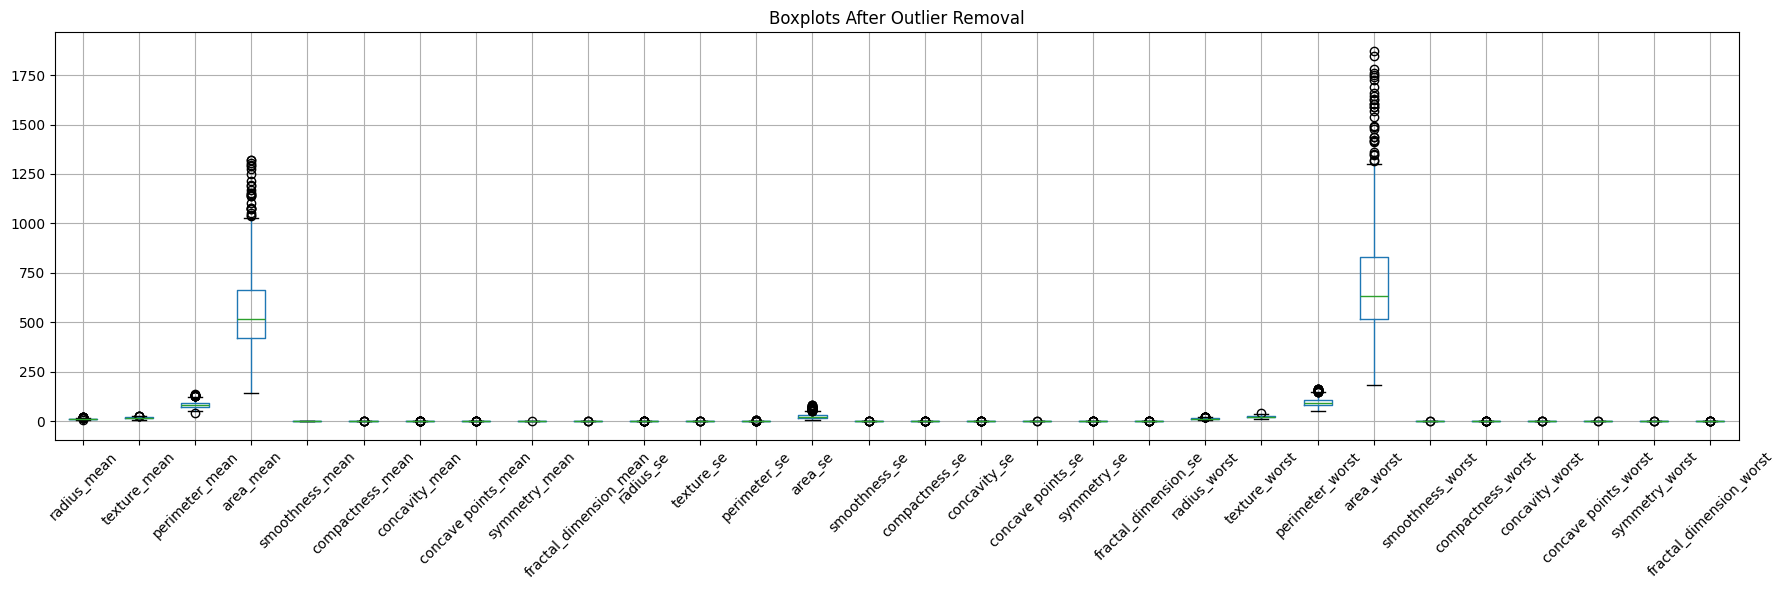

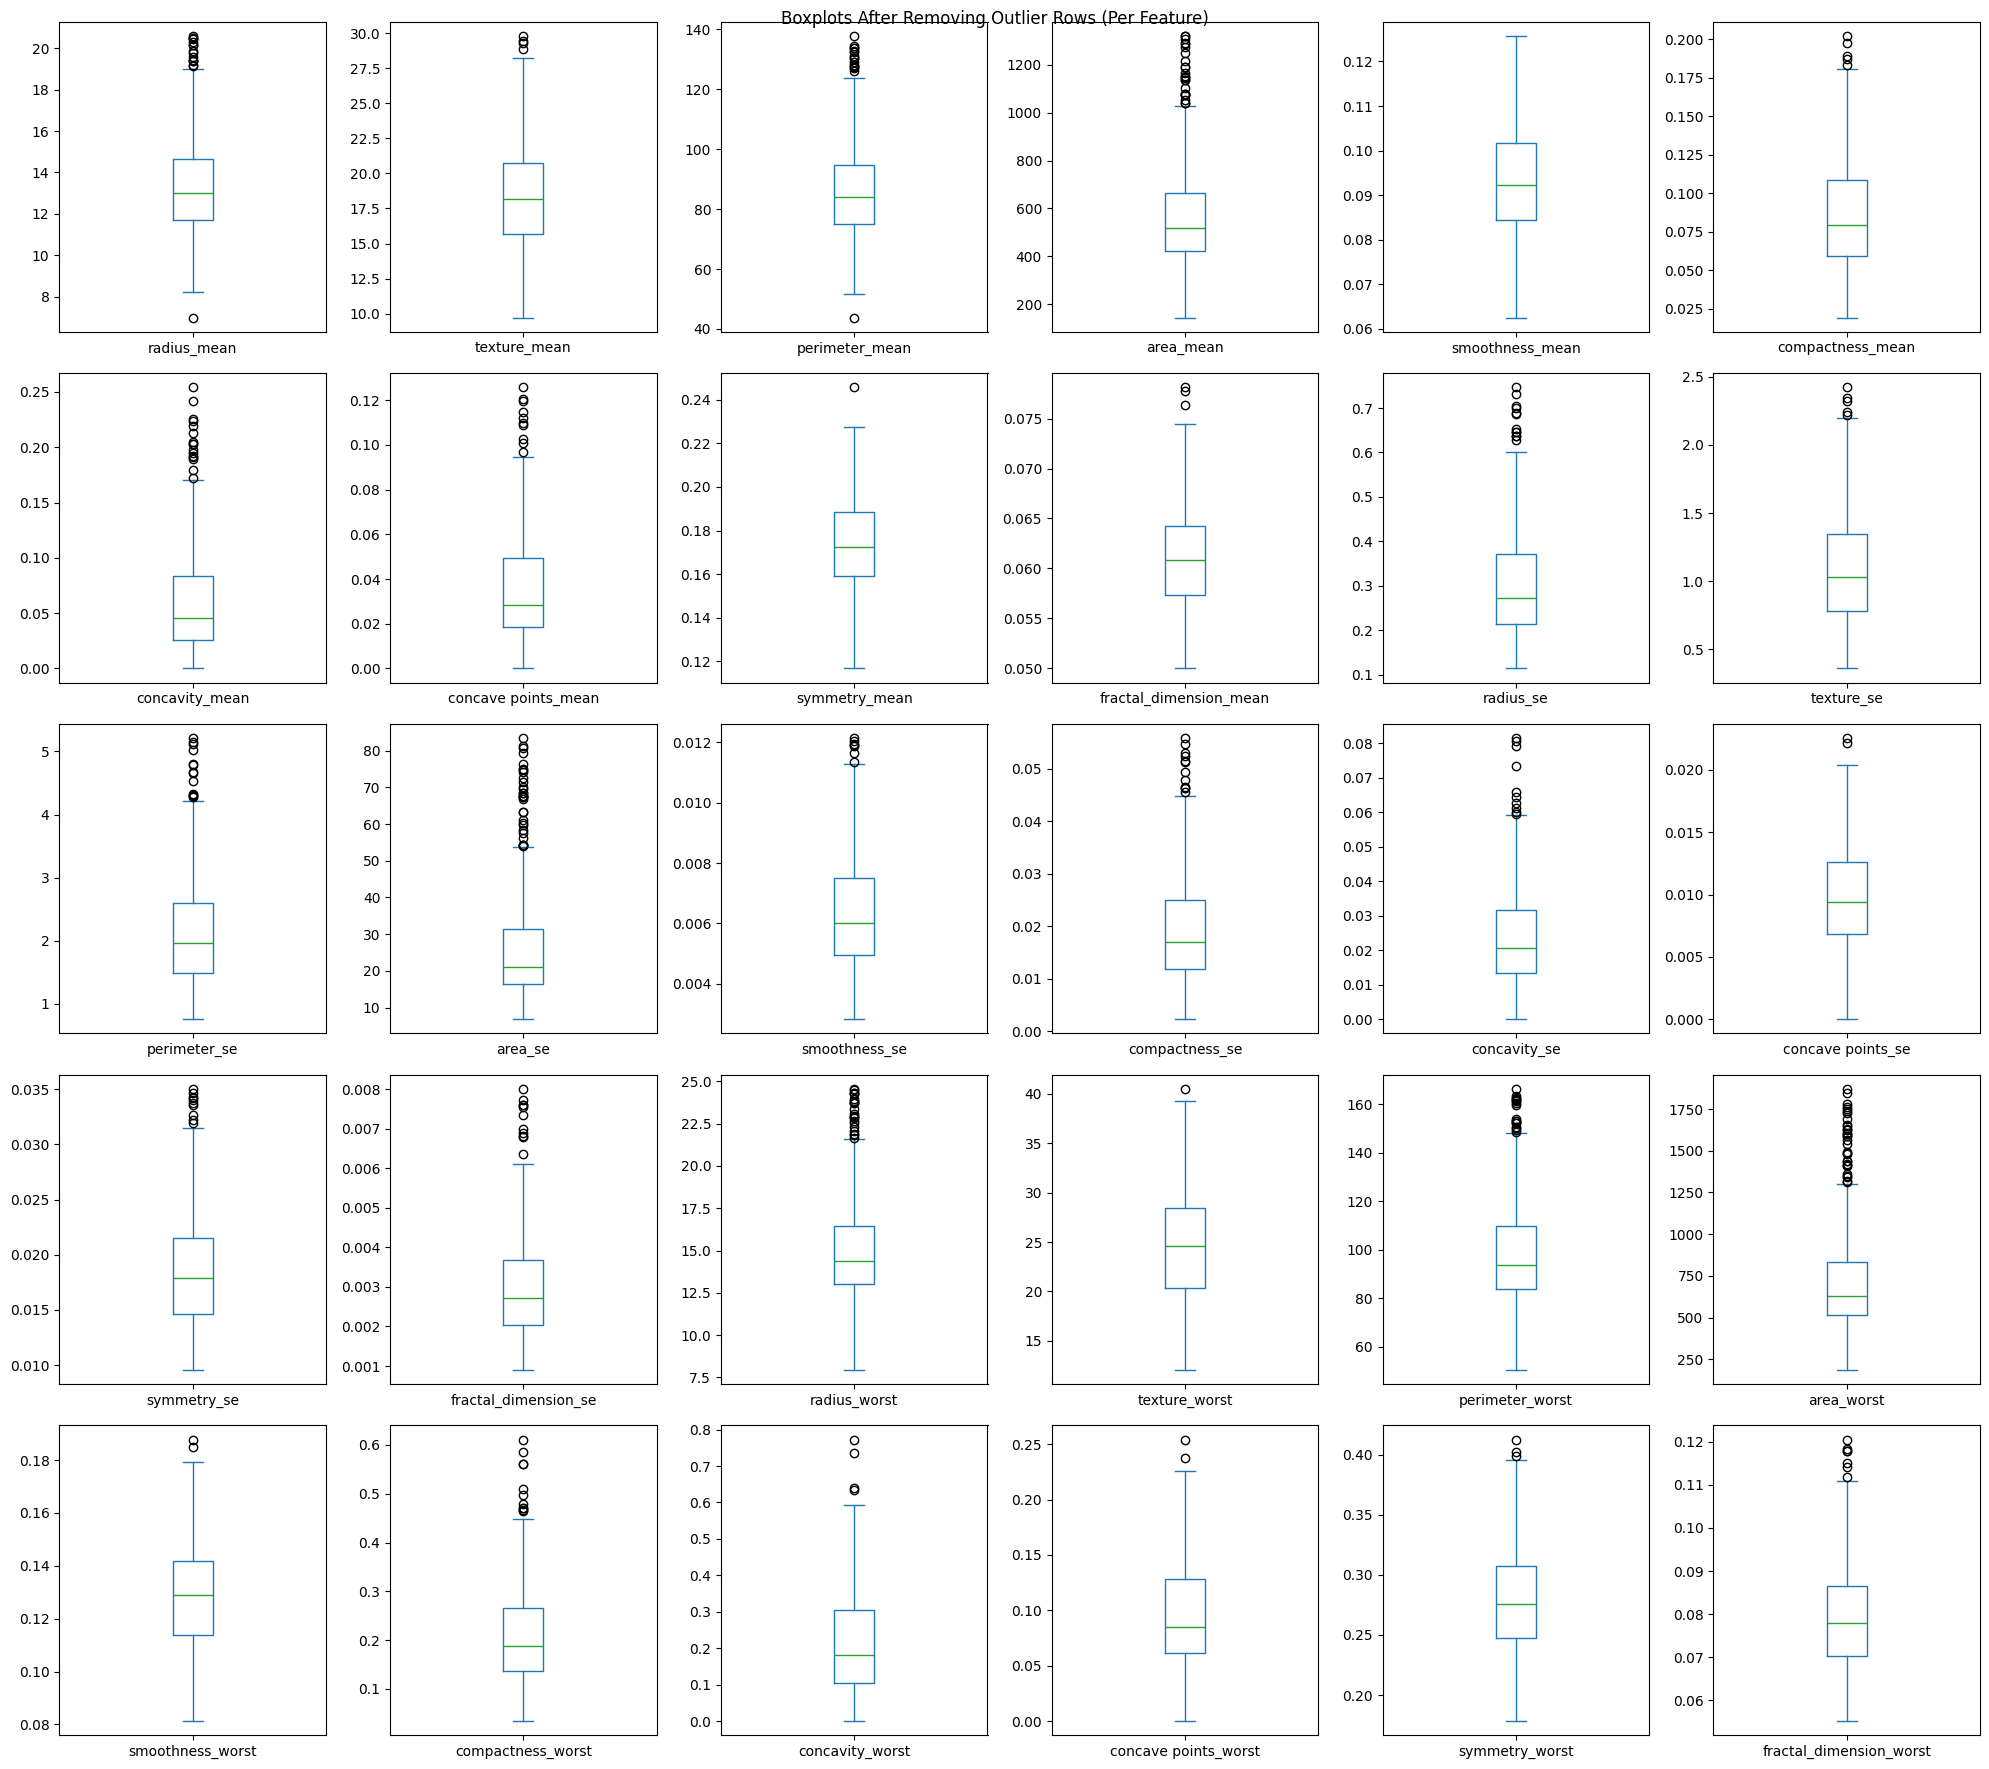

In [15]:
# boxplots after removing outlier rows
plt.figure(figsize=(18, 6))
df_cleaned[num_col].boxplot()
plt.title("Boxplots After Outlier Removal")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df_cleaned[num_col].plot.box(
    subplots=True,
    layout=(5, 6),
    figsize=(20, 18),
    sharey=False,
    title='Boxplots After Removing Outlier Rows (Per Feature)'
)
plt.tight_layout()
plt.show()

#  Normalization using Z-Score

In [16]:

# --- Scaling the data using Z-score (Standardization) ---
# create scaler object
scaler = StandardScaler()

# copy cleaned dataset so original stays unchanged
df_scaled = df_cleaned.copy()

# apply scaling on all numeric columns except the target (diagnosis)
df_scaled[num_col] = scaler.fit_transform(df_cleaned[num_col])

# print few rows to check
print("After scaling:")
print(df_scaled.head())


After scaling:
    diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
6           1     1.964461      0.377377        1.973596   2.108920   
7           1     0.134540      0.594978        0.225722   0.033027   
10          1     1.065623      1.211941        0.968866   1.020884   
11          1     0.968887     -0.157666        1.022372   0.945414   
13          1     0.997102      1.393701        1.028317   0.953051   

    smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
6          0.112751          0.650915        1.066356             1.488638   
7          2.126689          2.239566        0.677832             0.935739   
10        -0.930314         -0.560180       -0.560181            -0.104415   
11         0.317713          1.229127        0.797817             1.178389   
13        -0.768502          0.399021        0.794553             0.693088   

    symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
6        0.277054

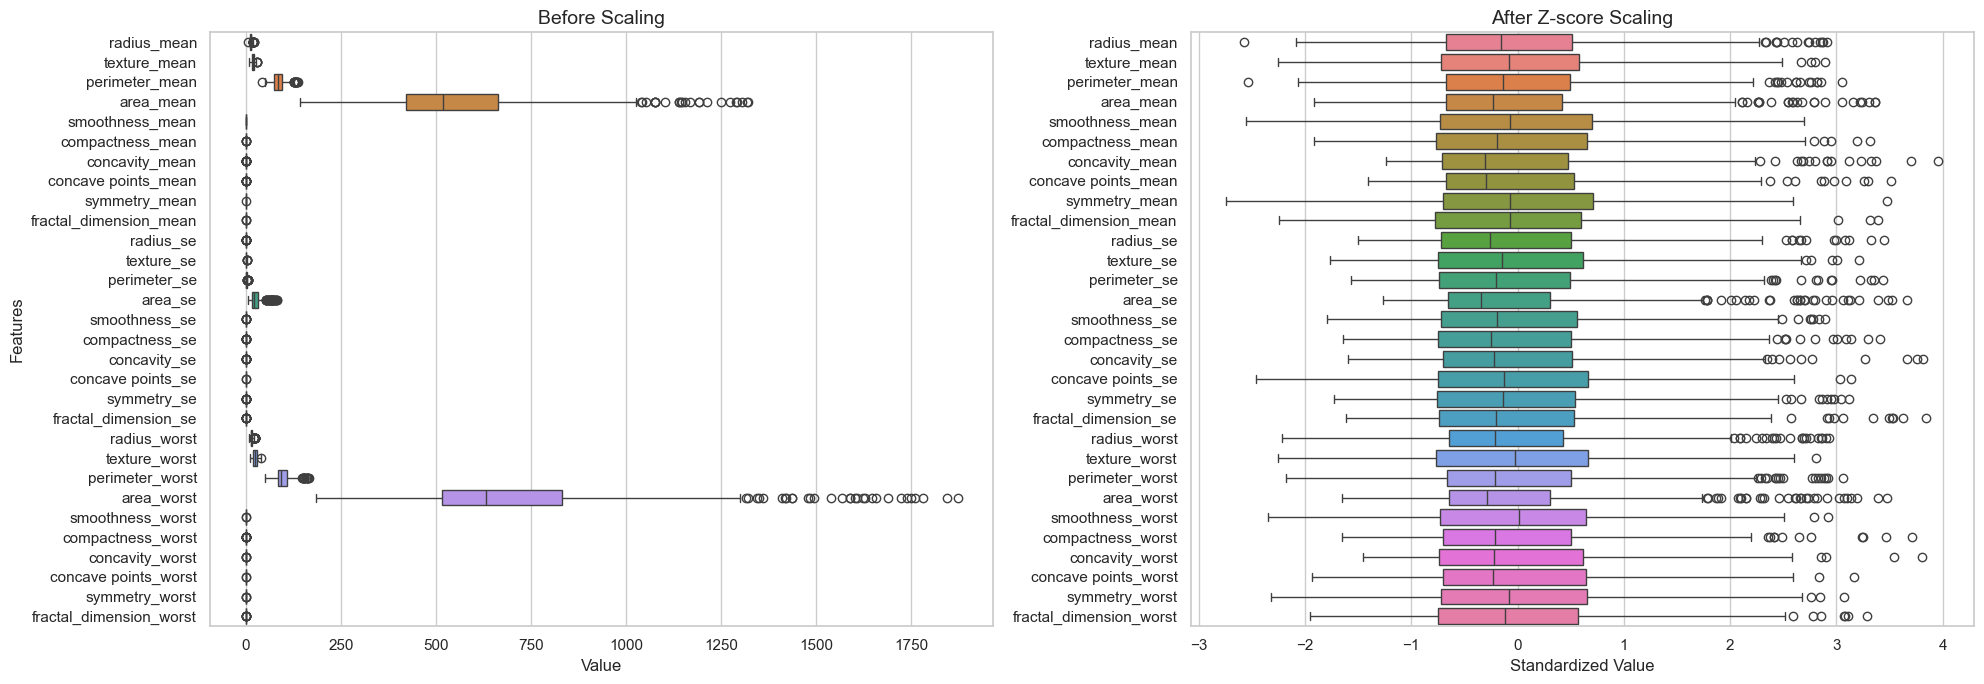

In [17]:

# --- Compare before and after scaling ---
sns.set(style="whitegrid")
plt.figure(figsize=(20, 7))

# BEFORE scaling
plt.subplot(1, 2, 1)
sns.boxplot(data=df_cleaned[num_col], orient="h")
plt.title("Before Scaling", fontsize=14)
plt.xlabel("Value")
plt.ylabel("Features")

# AFTER scaling
plt.subplot(1, 2, 2)
sns.boxplot(data=df_scaled[num_col], orient="h")
plt.title("After Z-score Scaling", fontsize=14)
plt.xlabel("Standardized Value")
plt.ylabel("")

plt.tight_layout()
plt.show()

In [18]:
# Z-Score Outlier Detection
from scipy import stats

# Calculate Z-scores for numerical columns
z_scores = np.abs(stats.zscore(df[num_col]))

# Define threshold
threshold = 3

# Identify outliers
z_outlier_mask = (z_scores > threshold)

In [19]:
# Count outliers per column
z_outlier_counts = z_outlier_mask.sum(axis=0)
print("Outliers per column using Z-score method:")
print(z_outlier_counts)

# Total outlier rows
z_row_outlier_mask = z_outlier_mask.any(axis=1)
z_outlier_count = z_row_outlier_mask.sum()
print(f"\nTotal rows with outliers (Z-score): {z_outlier_count}")

Outliers per column using Z-score method:
[ 5  4  7  8  5  9  9  6  5  7  7  9  8  6  7 12  6  6 11 10  6  4  6 10
  3 10  7  0  9  9]

Total rows with outliers (Z-score): 74


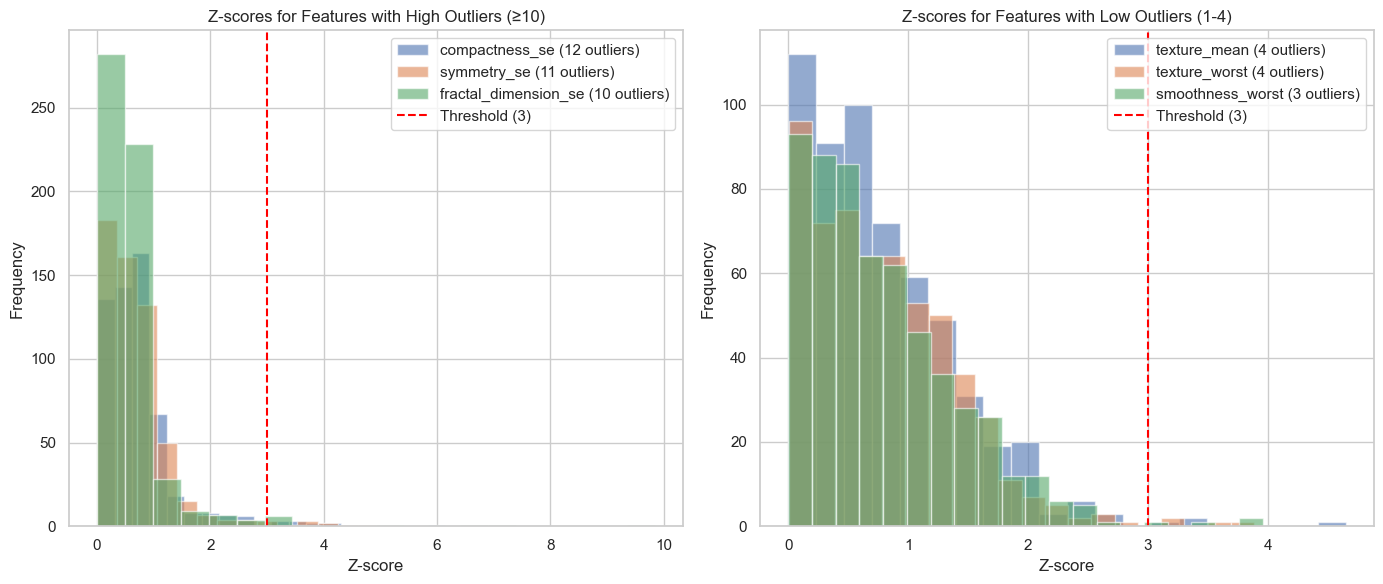

In [20]:
# Visualize Z-scores for features with high outliers vs low outliers
plt.figure(figsize=(14, 6))

# Define high and low outlier features
high_outlier_features = [i for i, count in enumerate(z_outlier_counts) if count >= 10]  # >= 10 outliers
low_outlier_features = [i for i, count in enumerate(z_outlier_counts) if 0 < count < 5]  # 1-4 outliers

# Plot for features with high outliers
plt.subplot(1, 2, 1)
for i in high_outlier_features[:3]:  # Top 3 high outlier features
    plt.hist(z_scores[:, i], bins=20, alpha=0.6, label=f'{num_col[i]} ({z_outlier_counts[i]} outliers)')
plt.axvline(threshold, color='red', linestyle='--', label='Threshold (3)')
plt.title('Z-scores for Features with High Outliers (≥10)')
plt.xlabel('Z-score')
plt.ylabel('Frequency')
plt.legend()

# Plot for features with low outliers
plt.subplot(1, 2, 2)
for i in low_outlier_features[:3]:  # Top 3 low outlier features
    plt.hist(z_scores[:, i], bins=20, alpha=0.6, label=f'{num_col[i]} ({z_outlier_counts[i]} outliers)')
plt.axvline(threshold, color='red', linestyle='--', label='Threshold (3)')
plt.title('Z-scores for Features with Low Outliers (1-4)')
plt.xlabel('Z-score')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

# Exploratory Data Analysis (EDA)

## 5.1 Distribution of Variables

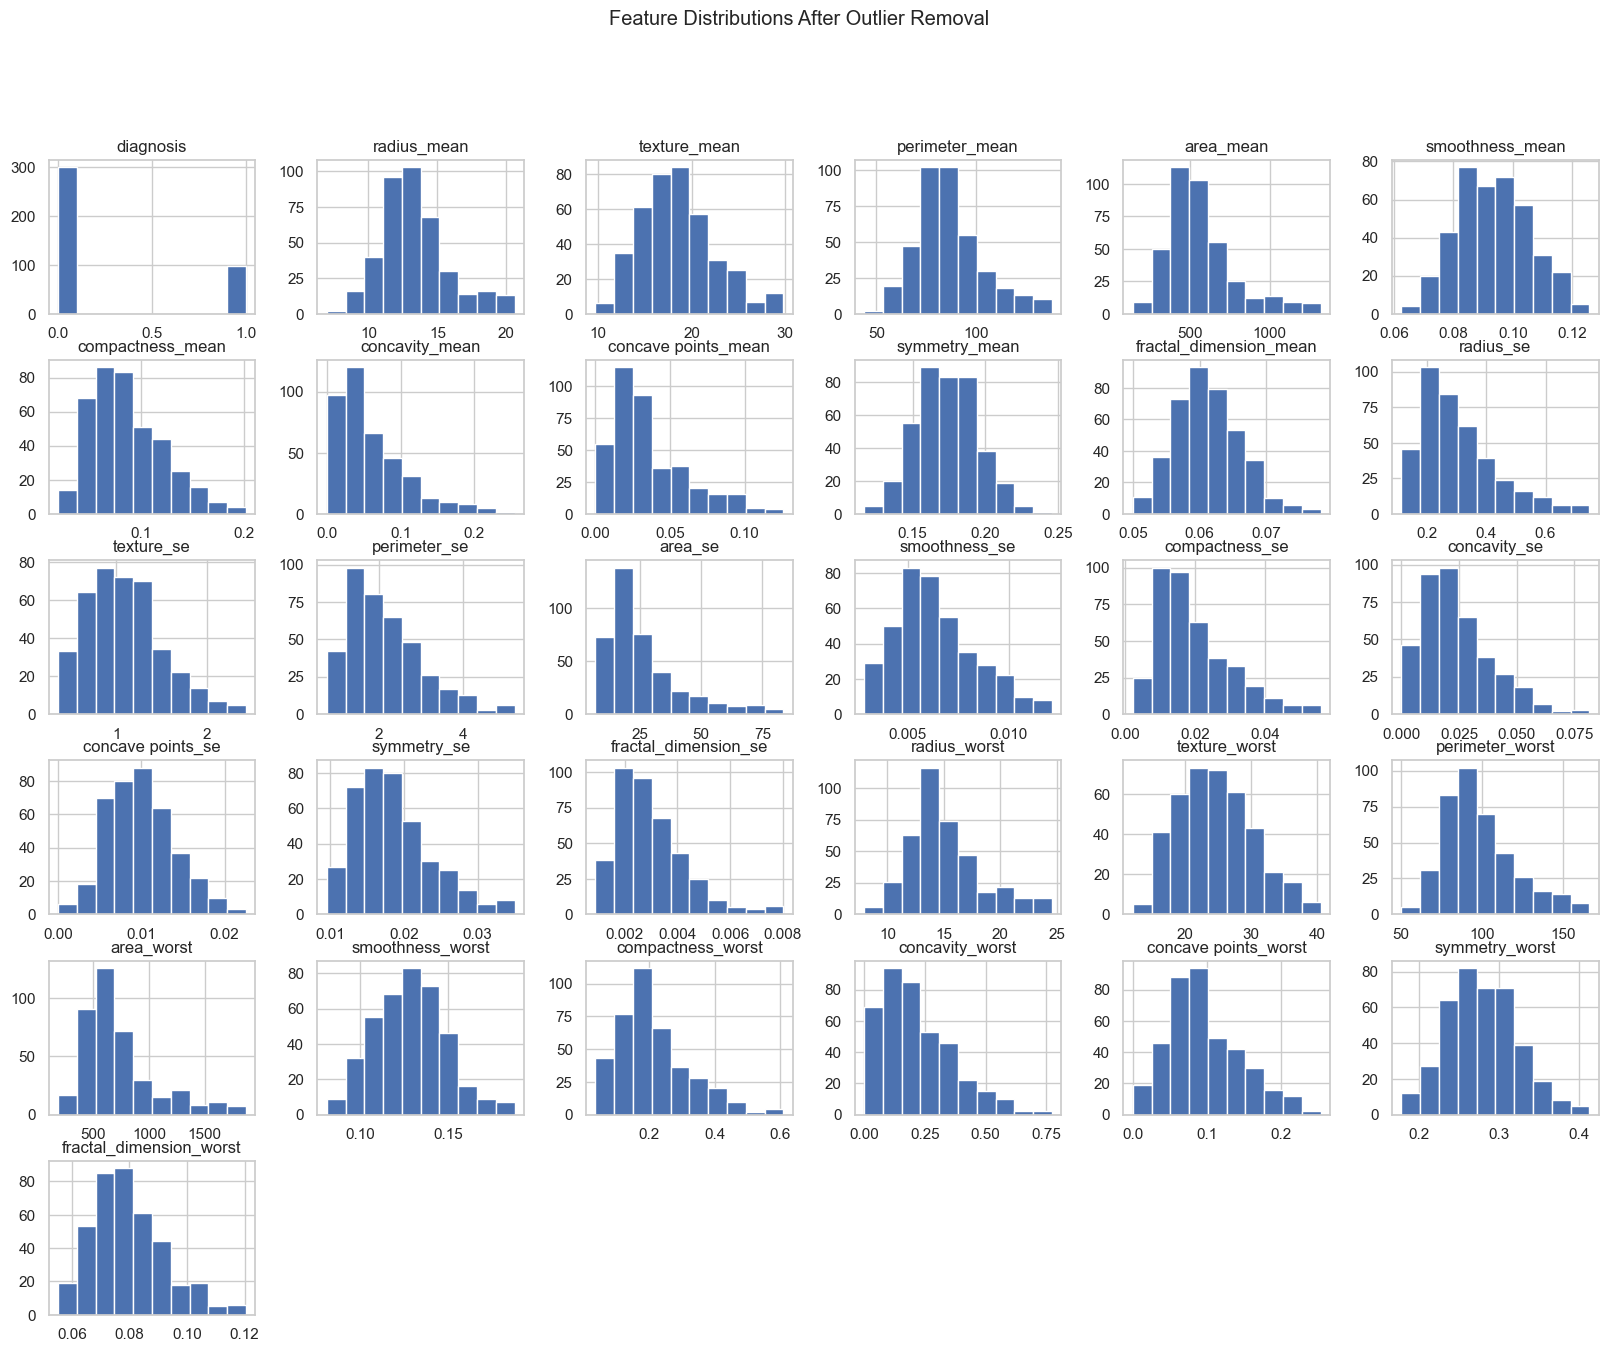

In [21]:
# Feature distribution histograms
df_cleaned.hist(figsize=(20, 15))
plt.suptitle("Feature Distributions After Outlier Removal")
plt.show()

In [22]:
# Skewness of each feature
skewness = df_cleaned[num_col].skew().sort_values(ascending=False)
print("\nSkewness of Features:")
print(skewness)


Skewness of Features:
area_se                    1.563842
concavity_mean             1.375196
area_worst                 1.374454
area_mean                  1.244330
fractal_dimension_se       1.192058
concave points_mean        1.153376
perimeter_se               1.062813
radius_se                  1.055441
compactness_se             1.015097
concavity_se               0.952016
compactness_worst          0.934002
radius_worst               0.909491
perimeter_worst            0.904028
concavity_worst            0.899557
symmetry_se                0.835542
compactness_mean           0.760204
fractal_dimension_worst    0.742950
perimeter_mean             0.741548
radius_mean                0.725130
smoothness_se              0.659143
texture_se                 0.641895
concave points_worst       0.595247
texture_mean               0.529933
fractal_dimension_mean     0.497689
concave points_se          0.361702
texture_worst              0.360090
symmetry_worst             0.319015
smoot

## 5.2 Variable Spread Analysis 

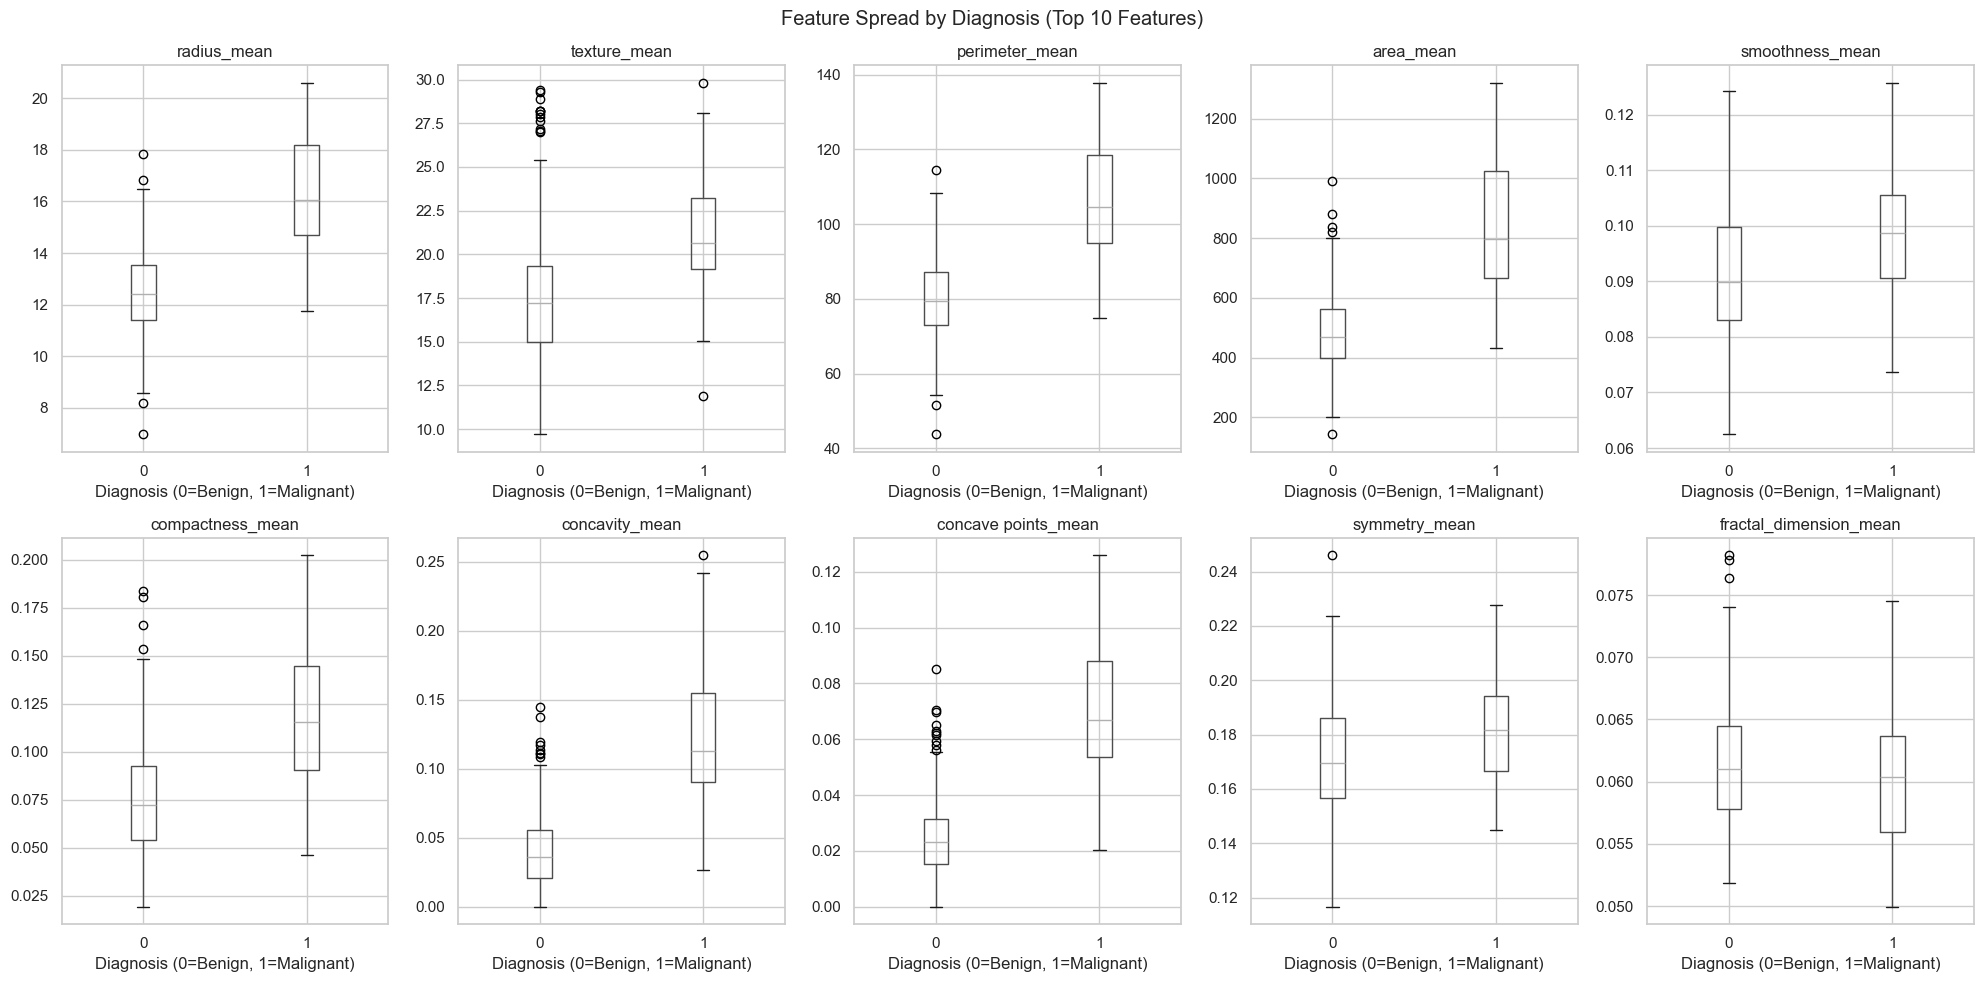

In [23]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, feature in enumerate(num_col[:10]):
    df_cleaned.boxplot(column=feature, by='diagnosis', ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_xlabel('Diagnosis (0=Benign, 1=Malignant)')

plt.suptitle('Feature Spread by Diagnosis (Top 10 Features)')
plt.tight_layout()
plt.show()

## 5.3 Relationship Between Variables 


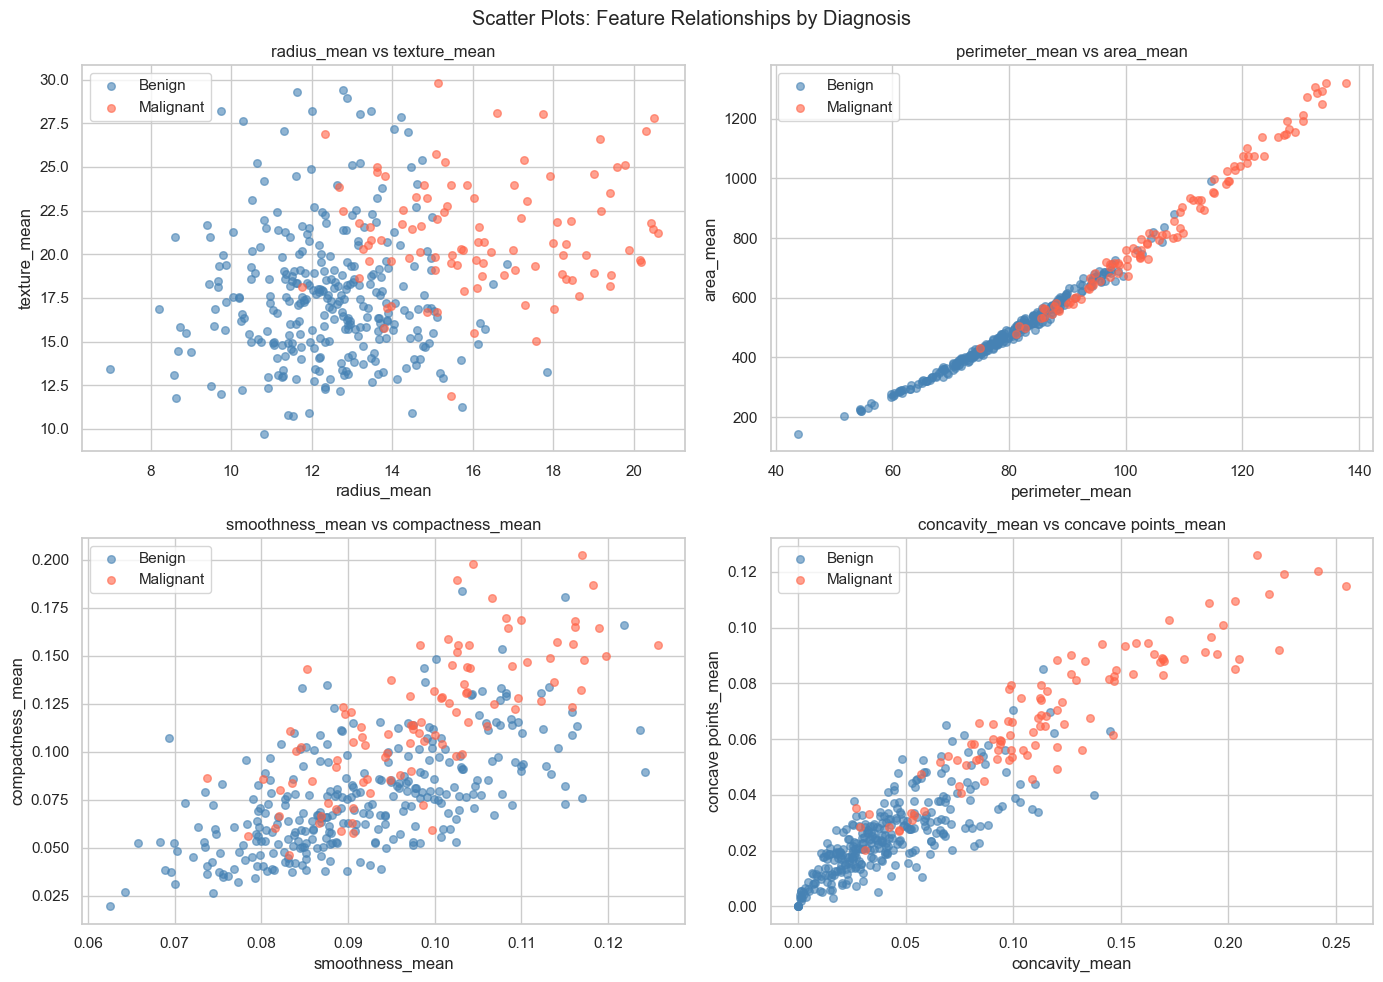

In [24]:
scatter_pairs = [(num_col[i], num_col[i+1]) for i in range(0, 8, 2)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = {0: 'steelblue', 1: 'tomato'}
labels = {0: 'Benign', 1: 'Malignant'}

for i, (x_feat, y_feat) in enumerate(scatter_pairs):
    for diag in [0, 1]:
        subset = df_cleaned[df_cleaned['diagnosis'] == diag]
        axes[i].scatter(subset[x_feat], subset[y_feat],
                        c=colors[diag], label=labels[diag], alpha=0.6, s=30)
    axes[i].set_xlabel(x_feat)
    axes[i].set_ylabel(y_feat)
    axes[i].set_title(f'{x_feat} vs {y_feat}')
    axes[i].legend()

plt.suptitle('Scatter Plots: Feature Relationships by Diagnosis')
plt.tight_layout()
plt.show()

## 5.4 Pairwise Feature Analysis

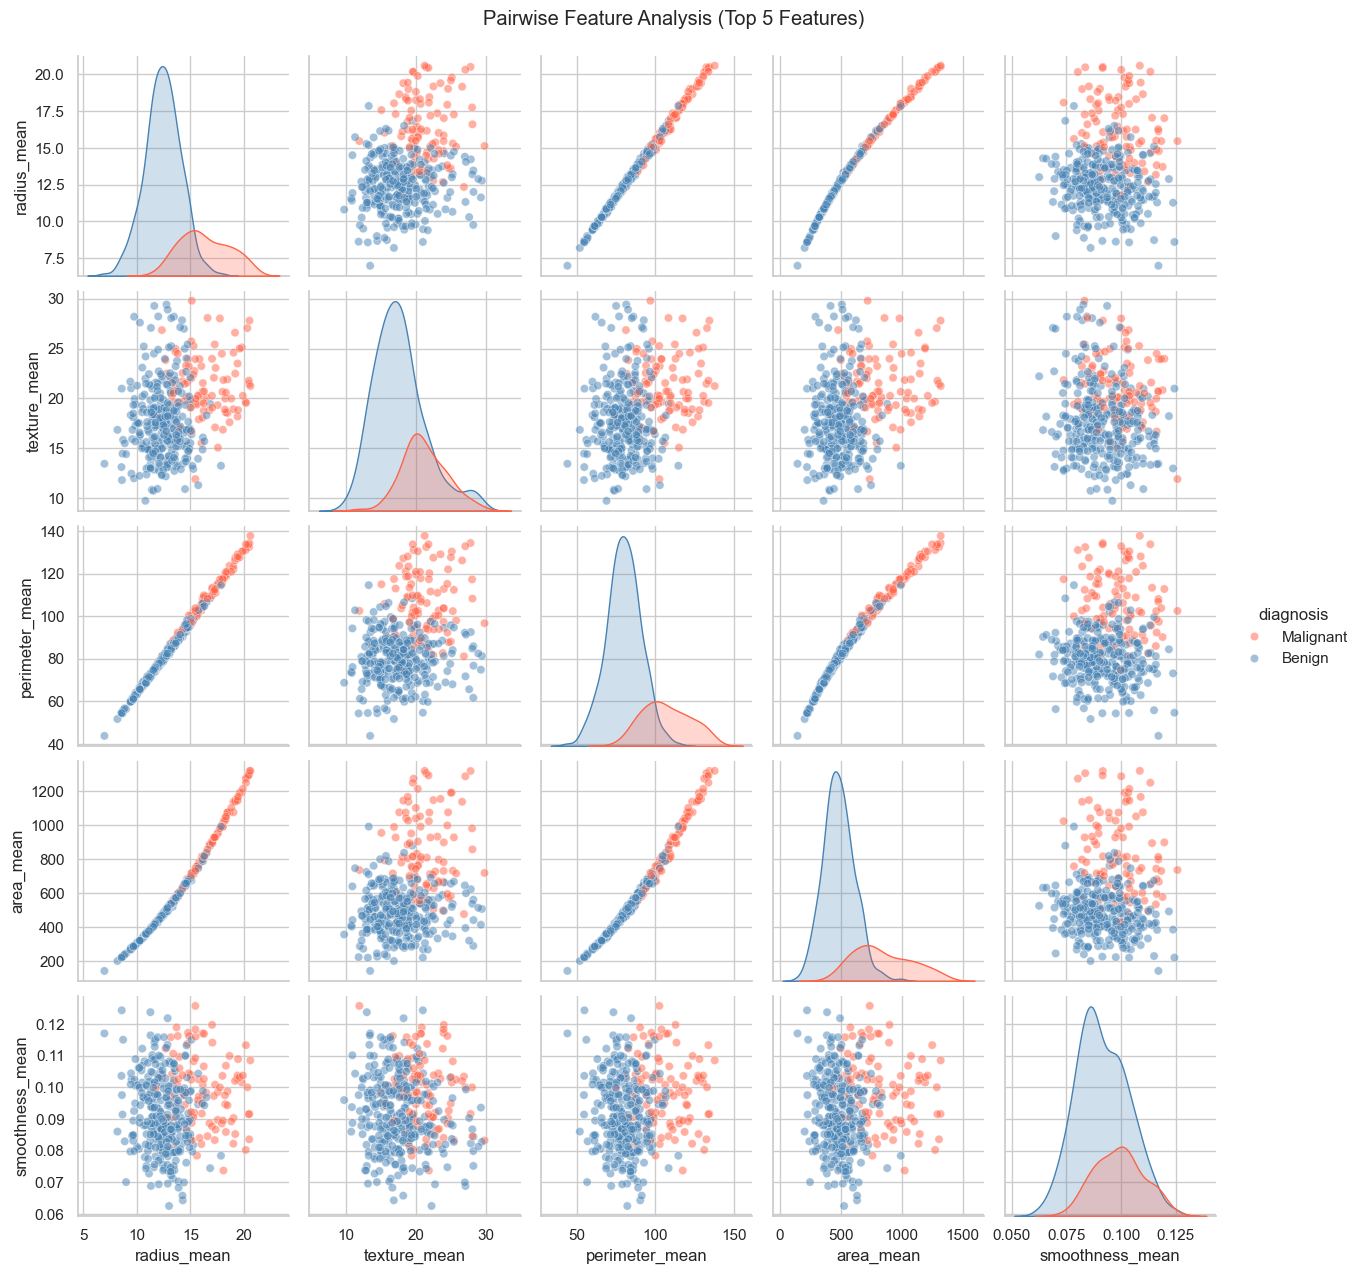

In [25]:
pair_features = num_col[:5].tolist() + ['diagnosis']
pair_df = df_cleaned[pair_features].copy()
pair_df['diagnosis'] = pair_df['diagnosis'].map({0: 'Benign', 1: 'Malignant'})

sns.pairplot(pair_df, hue='diagnosis',
             palette={'Benign': 'steelblue', 'Malignant': 'tomato'},
             diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairwise Feature Analysis (Top 5 Features)', y=1.02)
plt.show()

#  Correlation Analysis

In [26]:
#  Correlation Matrix
corr_matrix = df_cleaned.corr()

print("===== Correlation Matrix =====\n")
print(corr_matrix)

===== Correlation Matrix =====

                         diagnosis  radius_mean  texture_mean  perimeter_mean  \
diagnosis                 1.000000     0.680705      0.388596        0.695835   
radius_mean               0.680705     1.000000      0.280796        0.998113   
texture_mean              0.388596     0.280796      1.000000        0.285880   
perimeter_mean            0.695835     0.998113      0.285880        1.000000   
area_mean                 0.698005     0.992047      0.288688        0.990235   
smoothness_mean           0.271570     0.055311     -0.046879        0.093196   
compactness_mean          0.514346     0.442360      0.181078        0.492915   
concavity_mean            0.710567     0.658031      0.295111        0.696240   
concave points_mean       0.752190     0.755607      0.239147        0.785954   
symmetry_mean             0.243588     0.075653      0.051037        0.102371   
fractal_dimension_mean   -0.086631    -0.436397     -0.110214       -0.393736

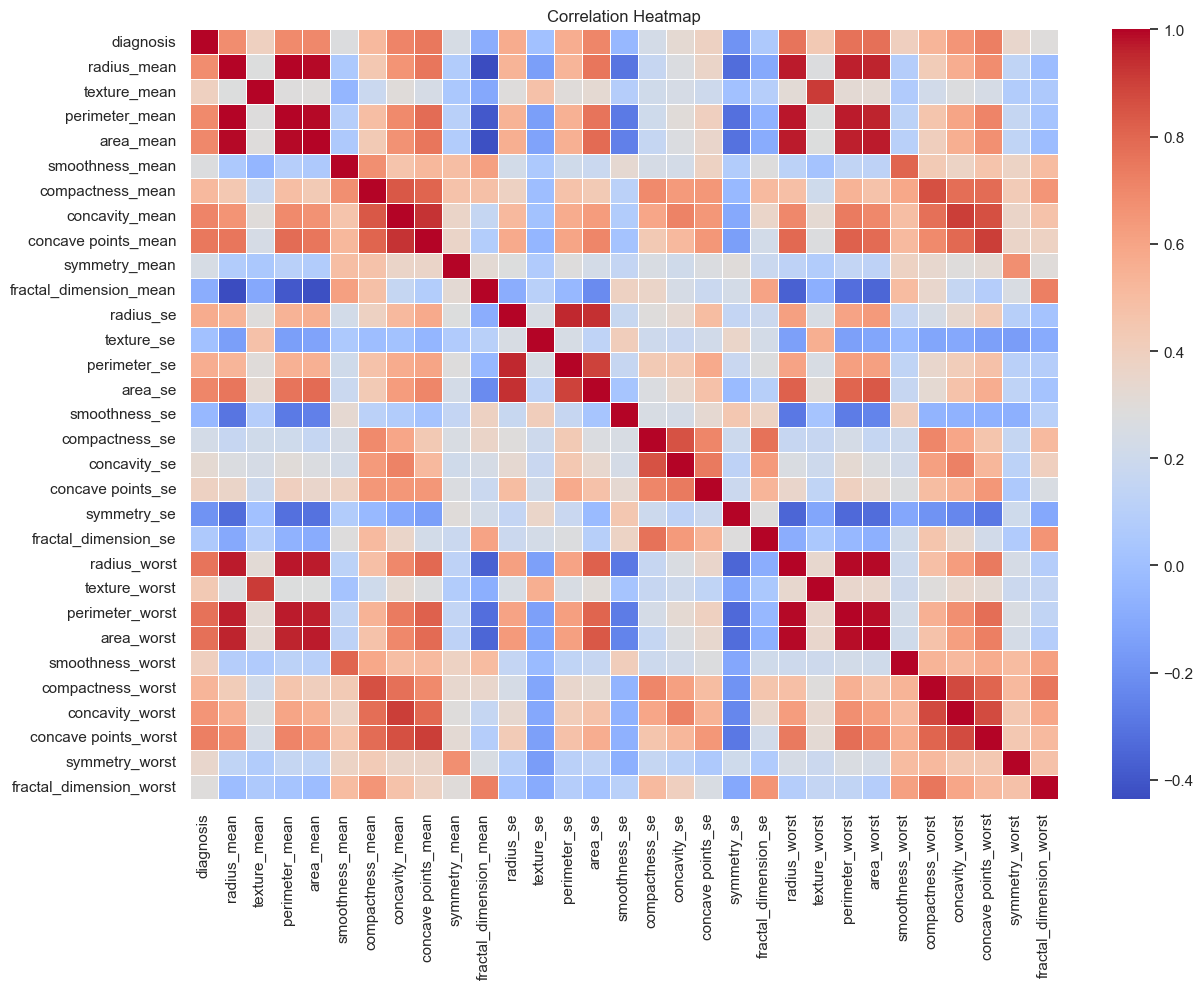

In [27]:
# Correlation Heatmap Visualization

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

In [28]:
# Correlation with Target Variable (diagnosis)
target_corr = corr_matrix['diagnosis'].sort_values(ascending=False)

print("\n===== Correlation with Target (diagnosis) =====\n")
print(target_corr)


===== Correlation with Target (diagnosis) =====

diagnosis                  1.000000
area_worst                 0.773626
perimeter_worst            0.768194
radius_worst               0.761081
concave points_mean        0.752190
concave points_worst       0.726639
concavity_mean             0.710567
area_se                    0.703715
area_mean                  0.698005
perimeter_mean             0.695835
radius_mean                0.680705
concavity_worst            0.653300
radius_se                  0.571842
perimeter_se               0.565909
compactness_worst          0.533996
compactness_mean           0.514346
texture_worst              0.437909
smoothness_worst           0.396847
texture_mean               0.388596
concave points_se          0.387972
symmetry_worst             0.347406
concavity_se               0.325974
fractal_dimension_worst    0.290821
smoothness_mean            0.271570
symmetry_mean              0.243588
compactness_se             0.229104
fractal_dimens

In [29]:
# Top Features (for later selection)

top_features = target_corr.abs().sort_values(ascending=False)[1:11]

print("\n===== Top 10 Important Features =====\n")
print(top_features)


===== Top 10 Important Features =====

area_worst              0.773626
perimeter_worst         0.768194
radius_worst            0.761081
concave points_mean     0.752190
concave points_worst    0.726639
concavity_mean          0.710567
area_se                 0.703715
area_mean               0.698005
perimeter_mean          0.695835
radius_mean             0.680705
Name: diagnosis, dtype: float64


In [30]:
# Set threshold
threshold = 0.9

# Get upper triangle of correlation matrix (to avoid duplicates)
corr_matrix = df_cleaned.corr()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find highly correlated pairs
high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notnull(upper.loc[row, col]) and abs(upper.loc[row, col]) > threshold
]

print("===== Highly Correlated Feature Pairs (>|0.9|) =====\n")
for pair in high_corr_pairs:
    print(f"{pair[0]}  <-->  {pair[1]}  =  {pair[2]:.3f}")

===== Highly Correlated Feature Pairs (>|0.9|) =====

perimeter_mean  <-->  radius_mean  =  0.998
area_mean  <-->  radius_mean  =  0.992
area_mean  <-->  perimeter_mean  =  0.990
concave points_mean  <-->  concavity_mean  =  0.930
perimeter_se  <-->  radius_se  =  0.951
area_se  <-->  radius_se  =  0.936
radius_worst  <-->  radius_mean  =  0.971
radius_worst  <-->  perimeter_mean  =  0.973
radius_worst  <-->  area_mean  =  0.969
texture_worst  <-->  texture_mean  =  0.915
perimeter_worst  <-->  radius_mean  =  0.965
perimeter_worst  <-->  perimeter_mean  =  0.972
perimeter_worst  <-->  area_mean  =  0.963
perimeter_worst  <-->  radius_worst  =  0.993
area_worst  <-->  radius_mean  =  0.958
area_worst  <-->  perimeter_mean  =  0.960
area_worst  <-->  area_mean  =  0.971
area_worst  <-->  radius_worst  =  0.991
area_worst  <-->  perimeter_worst  =  0.985
concavity_worst  <-->  concavity_mean  =  0.905
concave points_worst  <-->  concave points_mean  =  0.908


In [31]:
# Get correlation with target
target_corr = corr_matrix['diagnosis']

# Filter moderate correlations (0.4 to 0.6)
moderate_corr = target_corr[(target_corr >= 0.4) & (target_corr <= 0.6)]

print("===== Moderate Correlations (0.4 - 0.6) =====\n")
print(moderate_corr.sort_values(ascending=False))

===== Moderate Correlations (0.4 - 0.6) =====

radius_se            0.571842
perimeter_se         0.565909
compactness_worst    0.533996
compactness_mean     0.514346
texture_worst        0.437909
Name: diagnosis, dtype: float64


In [32]:
# Weak correlations (-0.2 to 0.2)
weak_corr = target_corr[(target_corr > -0.2) & (target_corr < 0.2)]

print("===== Weak Correlations (-0.2 to 0.2) =====\n")
print(weak_corr.sort_values())

===== Weak Correlations (-0.2 to 0.2) =====

symmetry_se              -0.194890
fractal_dimension_mean   -0.086631
smoothness_se            -0.036030
texture_se                0.007755
fractal_dimension_se      0.062799
Name: diagnosis, dtype: float64


In [33]:
negative_corr = target_corr[target_corr < 0]

print("===== Negative Correlations =====\n")
print(negative_corr.sort_values())

===== Negative Correlations =====

symmetry_se              -0.194890
fractal_dimension_mean   -0.086631
smoothness_se            -0.036030
Name: diagnosis, dtype: float64


# Classification Models
## 1. Decision Trees

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, auc

# Separate features and target
X = df_scaled  # Use scaled features
y = df_scaled['diagnosis']  # Target variable

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTarget distribution in training set:")
print(y_train.value_counts())
print("\nTarget distribution in test set:")
print(y_test.value_counts())

Training set size: (318, 31)
Test set size: (80, 31)

Target distribution in training set:
diagnosis
0    240
1     78
Name: count, dtype: int64

Target distribution in test set:
diagnosis
0    60
1    20
Name: count, dtype: int64


## 1.1 Hyperparameter Tuning with GridSearchCV

In [37]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [5, 10, 15, 20],
    'min_samples_split': [5, 10, 15]
}

# Grid search with cross-validation
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid,
    cv=5,              # 5-fold cross-validation
    scoring='roc_auc'  # Metric to optimize
)

print("Running GridSearchCV (this may take a moment)...")
grid_search.fit(X_train, y_train)

print("\n" + "="*60)
print("HYPERPARAMETER TUNING RESULTS")
print("="*60)
print("Best parameters:", grid_search.best_params_)
print(f"Best CV score (ROC-AUC): {grid_search.best_score_:.4f}")
print("="*60)

Running GridSearchCV (this may take a moment)...

HYPERPARAMETER TUNING RESULTS
Best parameters: {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 5}
Best CV score (ROC-AUC): 1.0000


In [38]:
# Use best parameters to build final model
best_dt = grid_search.best_estimator_

# Make predictions with best model
y_pred_train = best_dt.predict(X_train)
y_pred_test = best_dt.predict(X_test)
y_pred_proba = best_dt.predict_proba(X_test)[:, 1]

print("\n✓ Final Decision Tree trained with best parameters!")
print("\nBest Model Parameters:")
print(f"  - Max Depth: {best_dt.max_depth}")
print(f"  - Min Samples Leaf: {best_dt.min_samples_leaf}")
print(f"  - Min Samples Split: {best_dt.min_samples_split}")
print(f"  - Number of leaves: {best_dt.get_n_leaves()}")
print(f"  - Tree depth: {best_dt.get_depth()}")


✓ Final Decision Tree trained with best parameters!

Best Model Parameters:
  - Max Depth: 3
  - Min Samples Leaf: 5
  - Min Samples Split: 5
  - Number of leaves: 4
  - Tree depth: 2


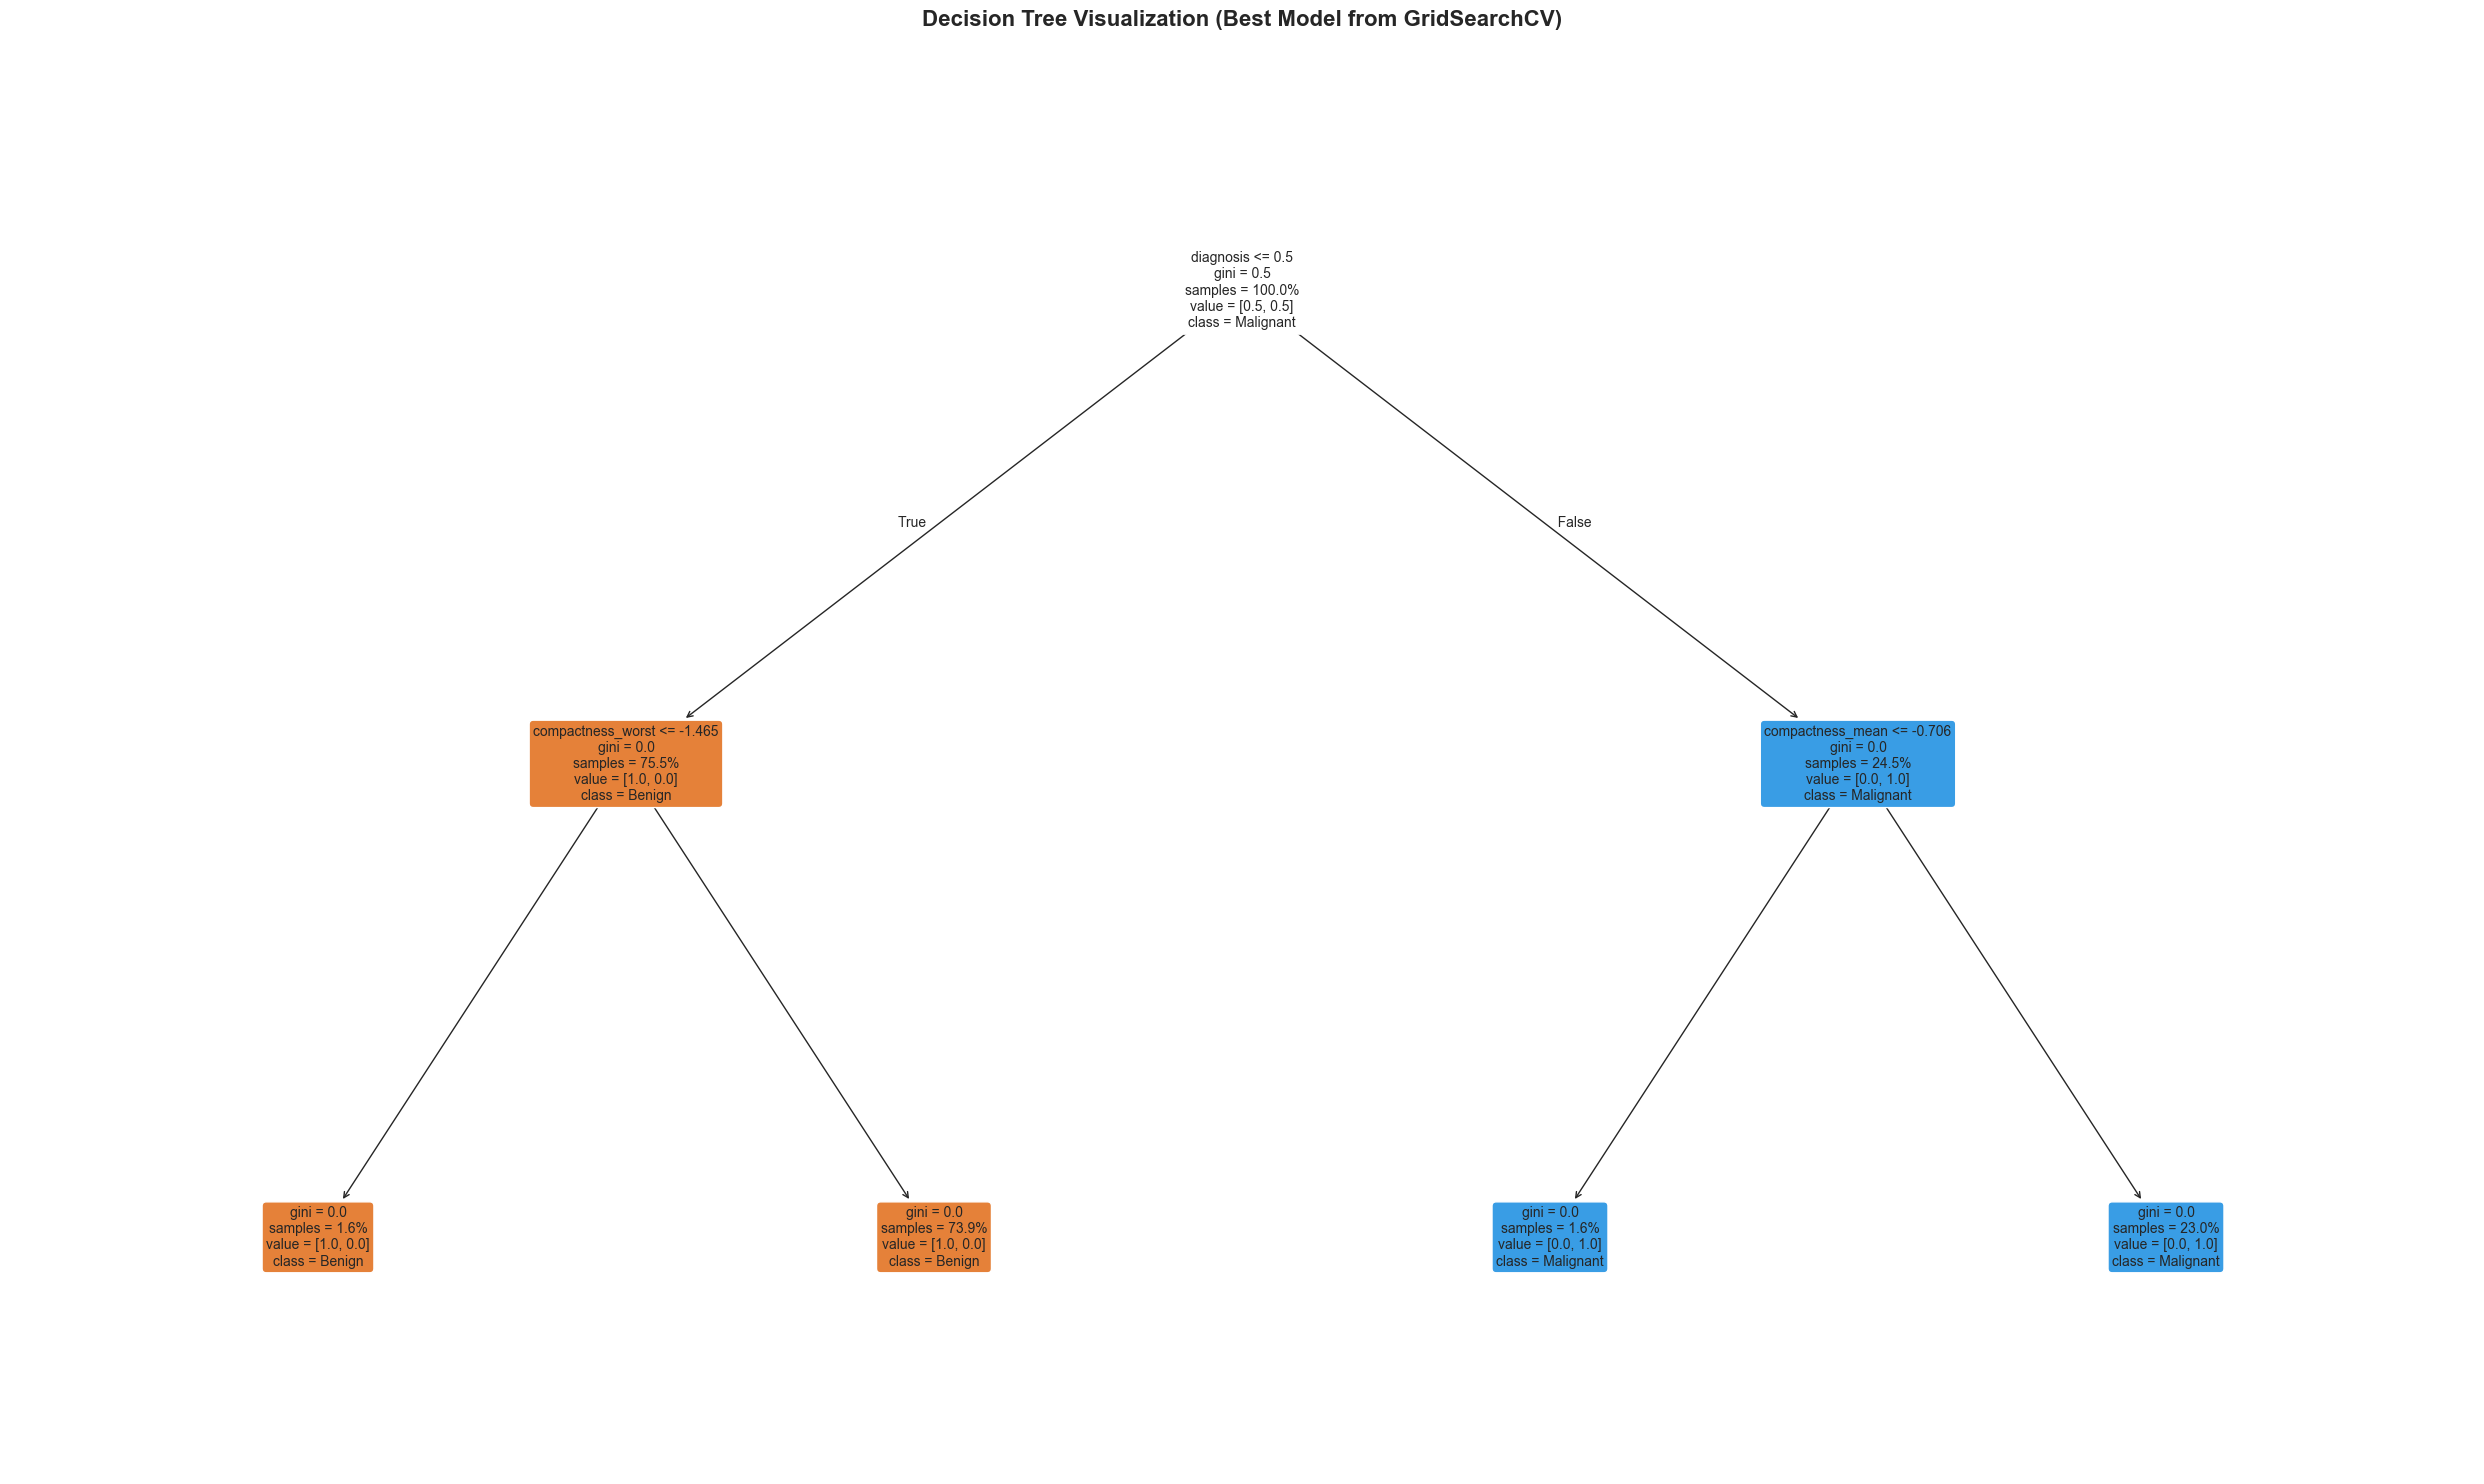

Decision Tree visualization saved to outputs/plots/decision_tree_visualization.png


In [39]:
from sklearn.tree import plot_tree

# Visualize the Decision Tree 
plt.figure(figsize=(25, 15))
plot_tree(best_dt, 
          feature_names=X_train.columns,
          class_names=['Benign', 'Malignant'],
          filled=True,
          rounded=True,
          fontsize=10,
          proportion=True)
plt.title("Decision Tree Visualization (Best Model from GridSearchCV)", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('outputs/plots/decision_tree_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("Decision Tree visualization saved to outputs/plots/decision_tree_visualization.png")

## 1.2 Evaluation Metrics

In [40]:
# Calculate evaluation metrics for Training Set
train_accuracy = accuracy_score(y_train, y_pred_train)
train_precision = precision_score(y_train, y_pred_train)
train_recall = recall_score(y_train, y_pred_train)
train_f1 = f1_score(y_train, y_pred_train)

# Calculate evaluation metrics for Test Set
test_accuracy = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test)
test_recall = recall_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test)

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Create metrics comparison table
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Training': [train_accuracy, train_precision, train_recall, train_f1, '-'],
    'Testing': [test_accuracy, test_precision, test_recall, test_f1, f'{roc_auc:.4f}']
})

print("="*60)
print("EVALUATION METRICS - DECISION TREE CLASSIFIER")
print("="*60)
print(metrics_df.to_string(index=False))
print("="*60)

EVALUATION METRICS - DECISION TREE CLASSIFIER
   Metric Training Testing
 Accuracy      1.0     1.0
Precision      1.0     1.0
   Recall      1.0     1.0
 F1-Score      1.0     1.0
  ROC-AUC        -  1.0000


## 1.3 Confusion Matrix

Confusion Matrix for Test Set:
[[60  0]
 [ 0 20]]

True Negatives (TN): 60
False Positives (FP): 0
False Negatives (FN): 0
True Positives (TP): 20


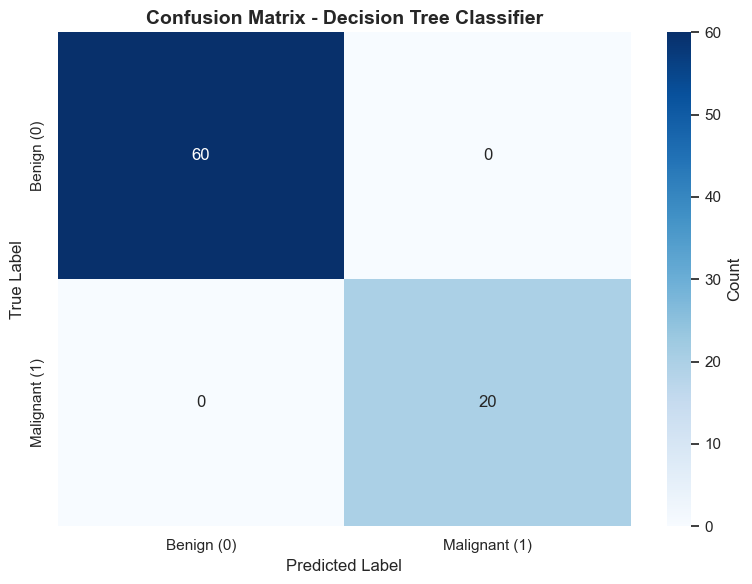


Confusion Matrix saved to outputs/plots/confusion_matrix_dt.png


In [41]:
# Calculate Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)

# Extract values
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix for Test Set:")
print(cm)
print(f"\nTrue Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

# Visualize Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'],
            cbar_kws={'label': 'Count'},
            ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix - Decision Tree Classifier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/confusion_matrix_dt.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nConfusion Matrix saved to outputs/plots/confusion_matrix_dt.png")

In [ ]:
# Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT - TEST SET")
print("="*60)
print(classification_report(y_test, y_pred_test, 
                            target_names=['Benign (0)', 'Malignant (1)']))

## 1.4 ROC-AUC Curve

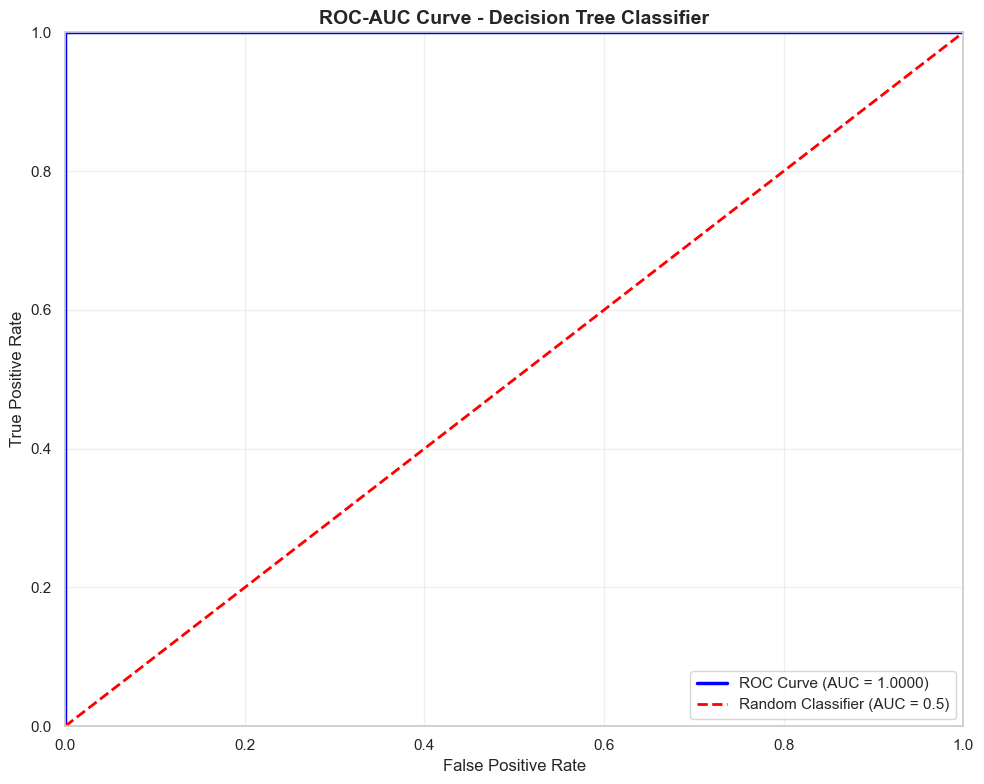


ROC-AUC Curve saved to outputs/plots/roc_auc_curve_dt.png
AUC Score: 1.0000


In [42]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot ROC curve
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the ROC curve
ax.plot(fpr, tpr, color='blue', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')

# Plot the diagonal line (random classifier)
ax.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')

# Formatting
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC-AUC Curve - Decision Tree Classifier', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('outputs/plots/roc_auc_curve_dt.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nROC-AUC Curve saved to outputs/plots/roc_auc_curve_dt.png")
print(f"AUC Score: {roc_auc:.4f}")

## 1.4 Model Performance Summary

In [ ]:
# Create comprehensive summary
summary = f"""
{'='*70}
DECISION TREE CLASSIFIER - FINAL PERFORMANCE SUMMARY
{'='*70}

MODEL DETAILS (BEST MODEL FROM GRIDSEARCHCV):
  - Max Depth: {best_dt.max_depth}
  - Number of Leaves: {best_dt.get_n_leaves()}
  - Tree Depth: {best_dt.get_depth()}
  - Min Samples Leaf: {best_dt.min_samples_leaf}
  - Min Samples Split: {best_dt.min_samples_split}
  - Random State: 42

TRAINING SET PERFORMANCE:
  - Accuracy:  {train_accuracy:.4f} ({train_accuracy*100:.2f}%)
  - Precision: {train_precision:.4f}
  - Recall:    {train_recall:.4f}
  - F1-Score:  {train_f1:.4f}

TEST SET PERFORMANCE:
  - Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)
  - Precision: {test_precision:.4f}
  - Recall:    {test_recall:.4f}
  - F1-Score:  {test_f1:.4f}
  - ROC-AUC:   {roc_auc:.4f}

CONFUSION MATRIX ANALYSIS (Test Set):
  - True Negatives (Correctly classified as Benign): {tn}
  - False Positives (Incorrectly classified as Malignant): {fp}
  - False Negatives (Incorrectly classified as Benign): {fn}
  - True Positives (Correctly classified as Malignant): {tp}

INTERPRETATION:
  ✓ The model achieves {test_accuracy*100:.2f}% accuracy on the test set
  ✓ ROC-AUC score of {roc_auc:.4f} indicates excellent discrimination ability
  ✓ High precision ({test_precision:.4f}) means low false positive rate
  ✓ High recall ({test_recall:.4f}) means ability to identify positive cases
  ✓ F1-Score of {test_f1:.4f} shows good balance between precision and recall
  ✓ Simple model (depth {best_dt.get_depth()}) is highly interpretable

{'='*70}
"""

print(summary)

# Save summary to file
with open('outputs/tables/model_summary_dt.txt', 'w') as f:
    f.write(summary)
print("\nModel summary saved to outputs/tables/model_summary_dt.txt")